# Assignment 4 — Time Series Forecasting, Refactored Version

This notebook is a cleaned version of the original assignment. The main fixes are:

- no hardcoded forecast index such as `start=132`
- MAPE is reported as a percentage
- validation forecasts use `len(Validate)` instead of a fixed 36 periods
- outlier detection does not mutate the input DataFrame
- model comparison uses one consistent metric format across all models
- imports and repeated logic are consolidated into reusable functions
- `Test` is copied before forecast columns are assigned

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.ar_model import AutoReg

import pmdarima as pm

pd.options.display.float_format = "{:.2f}".format

## Helper functions

These functions replace repeated code blocks in the original notebook.

In [2]:
def adf_summary(series, name=None):
    """Run the Augmented Dickey-Fuller test and return a one-row summary."""
    clean_series = pd.Series(series).dropna()
    statistic, p_value, used_lag, n_obs, critical_values, ic_best = adfuller(clean_series)
    return pd.DataFrame({
        "Series": [name or clean_series.name],
        "ADF Statistic": [statistic],
        "p-value": [p_value],
        "Used Lag": [used_lag],
        "Observations": [n_obs],
        "Stationary at 5%": [p_value < 0.05]
    })


def mape_percent(y_true, y_pred):
    """Return MAPE as a percentage while ignoring zero actual values."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def regression_metrics(y_true, y_pred, model_name, target_name):
    """Return MAE, RMSE, and MAPE% for a forecast."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    if len(y_true) != len(y_pred):
        raise ValueError(
            f"Length mismatch for {model_name} / {target_name}: "
            f"actual={len(y_true)}, forecast={len(y_pred)}"
        )

    return pd.DataFrame({
        "Model": [model_name],
        "Target": [target_name],
        "MAE": [mean_absolute_error(y_true, y_pred)],
        "RMSE": [np.sqrt(mean_squared_error(y_true, y_pred))],
        "MAPE (%)": [mape_percent(y_true, y_pred)]
    })


def detect_outliers(data, column, window=12, threshold=3):
    """
    Detect outliers using moving-average residuals without mutating the input DataFrame.
    Returns: outliers, diagnostic_data
    """
    diagnostic_data = data.copy()
    diagnostic_data[f"MA_{column}"] = diagnostic_data[column].rolling(
        window=window,
        center=True,
        min_periods=max(2, window // 2)
    ).mean()
    diagnostic_data[f"Residual_{column}"] = diagnostic_data[column] - diagnostic_data[f"MA_{column}"]

    residual_std = diagnostic_data[f"Residual_{column}"].std()
    outlier_mask = diagnostic_data[f"Residual_{column}"].abs() > threshold * residual_std
    outliers = diagnostic_data.loc[outlier_mask].copy()

    return outliers, diagnostic_data


def plot_ewma(data, column, alphas=(0.2, 0.5, 0.8)):
    """Plot original data with EWMA lines."""
    fig, ax = plt.subplots(figsize=(12, 6), facecolor="white")
    ax.set_facecolor("white")

    ax.plot(data["Date"], data[column], label=f"Original {column}", linewidth=2)

    for alpha in alphas:
        ewma = data[column].ewm(alpha=alpha, adjust=False).mean()
        ax.plot(data["Date"], ewma, label=f"EWMA alpha={alpha}", linewidth=1.5)

    ax.set_title(f"EWMA Smoothing for {column}")
    ax.set_xlabel("Date")
    ax.set_ylabel(column)
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Load and prepare data

In [3]:
city_dash = pd.read_csv("Toronto's Dashboard - Key metrics.csv")
city_dash = city_dash.loc[city_dash["period_number_in_year"] <= 12].copy()

city_dash["Date"] = pd.to_datetime(
    city_dash["year"].astype(str) + "/" + city_dash["period_number_in_year"].astype(str) + "/01"
)

house_price = city_dash.loc[
    city_dash["measure_name"] == "Average Home Price (City of Toronto)",
    ["Date", "measure_value"]
].rename(columns={"measure_value": "House_Price"})

house_sales = city_dash.loc[
    city_dash["measure_name"] == "Number of Home Sales (City of Toronto)",
    ["Date", "measure_value"]
].rename(columns={"measure_value": "House_Sales"})

combined_data = (
    pd.merge(house_price, house_sales, on="Date", how="inner")
    .sort_values("Date")
    .reset_index(drop=True)
)

# Clear, consistent differencing names
combined_data["House_Price_Diff1"] = combined_data["House_Price"].diff()
combined_data["House_Price_Diff2"] = combined_data["House_Price_Diff1"].diff()
combined_data["House_Sales_Diff1"] = combined_data["House_Sales"].diff()

# Backward-compatible aliases used later in the assignment
combined_data["Price_Change"] = combined_data["House_Price_Diff2"]
combined_data["Sales_Change"] = combined_data["House_Sales_Diff1"]

combined_data = combined_data.dropna().reset_index(drop=True)
combined_data.head()

,Date,House_Price,House_Sales,House_Price_Diff1,House_Price_Diff2,House_Sales_Diff1,Price_Change,Sales_Change
0,2009-03-01,387793.00,2398.00,-5126.00,-33629.00,745.00,-33629.00,745.00
1,2009-04-01,421470.00,3222.00,33677.00,38803.00,824.00,38803.00,824.00
2,2009-05-01,432478.00,3777.00,11008.00,-22669.00,555.00,-22669.00,555.00
3,2009-06-01,441703.00,4362.00,9225.00,-1783.00,585.00,-1783.00,585.00
4,2009-07-01,421110.00,3880.00,-20593.00,-29818.00,-482.00,-29818.00,-482.00


## Train / validation / test split

In [4]:
TEST_START_DATE = pd.Timestamp("2020-01-01")
VALIDATION_START_DATE = pd.Timestamp("2017-01-01")

Train_data = combined_data.loc[combined_data["Date"] < TEST_START_DATE].copy()
Test = combined_data.loc[combined_data["Date"] >= TEST_START_DATE].copy()

Train = Train_data.loc[Train_data["Date"] < VALIDATION_START_DATE].copy()
Validate = Train_data.loc[Train_data["Date"] >= VALIDATION_START_DATE].copy()

print(f"Train rows: {len(Train)}")
print(f"Validate rows: {len(Validate)}")
print(f"Test rows: {len(Test)}")

Train rows: 94
Validate rows: 36
Test rows: 60


## Stationarity checks

In [5]:
adf_results = pd.concat([
    adf_summary(Train["House_Price"], "House_Price"),
    adf_summary(Train["House_Sales"], "House_Sales"),
    adf_summary(Train["House_Price_Diff1"], "House_Price_Diff1"),
    adf_summary(Train["House_Price_Diff2"], "House_Price_Diff2"),
    adf_summary(Train["House_Sales_Diff1"], "House_Sales_Diff1"),
], ignore_index=True)

adf_results

,Series,ADF Statistic,p-value,Used Lag,Observations,Stationary at 5%
0,House_Price,3.42,1.00,12,81,False
1,House_Sales,-2.18,0.21,12,81,False
2,House_Price_Diff1,-1.81,0.38,12,81,False
3,House_Price_Diff2,-10.02,0.00,11,82,True
4,House_Sales_Diff1,-3.69,0.00,11,82,True


## Outlier detection

This version does not add `MA_` or `Residual_` columns to the original `Train` DataFrame.

In [6]:
outliers_price, price_diagnostics = detect_outliers(Train, "Price_Change", window=12, threshold=3)
outliers_sales, sales_diagnostics = detect_outliers(Train, "Sales_Change", window=12, threshold=3)

outlier_indices = outliers_price.index.union(outliers_sales.index)
Train_clean = Train.drop(index=outlier_indices).copy()

print(f"Price outliers: {len(outliers_price)}")
print(f"Sales outliers: {len(outliers_sales)}")
print(f"Rows removed: {len(outlier_indices)}")
print(f"Clean training rows: {len(Train_clean)}")

Price outliers: 0
Sales outliers: 0
Rows removed: 0
Clean training rows: 94


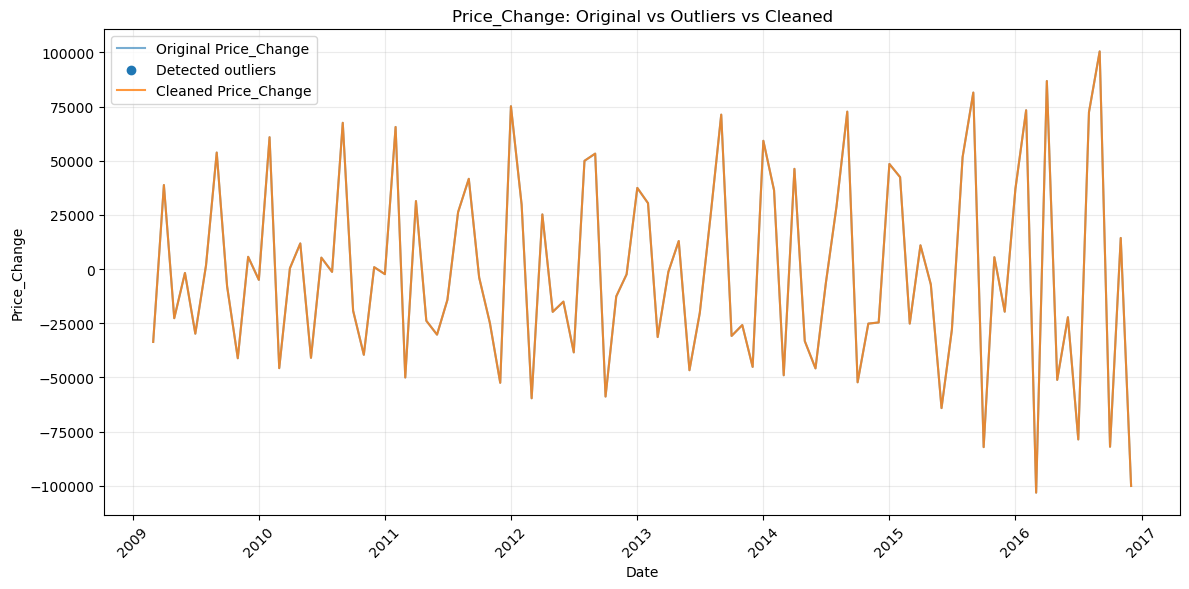

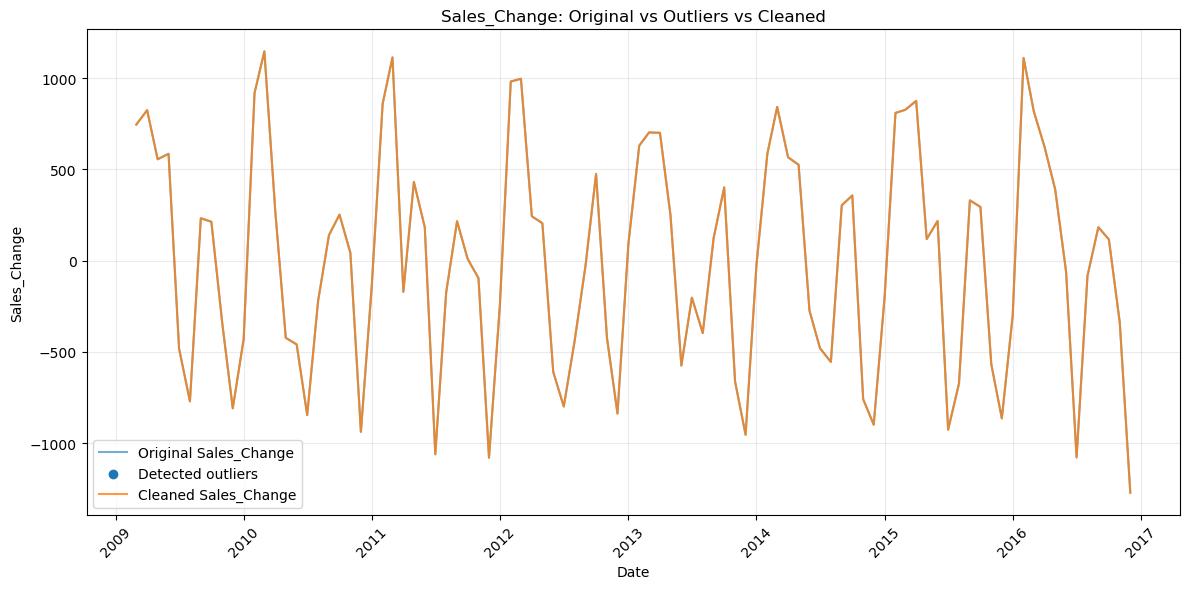

In [7]:
def plot_outliers_comparison(original_data, outliers, cleaned_data, column):
    fig, ax = plt.subplots(figsize=(12, 6), facecolor="white")
    ax.set_facecolor("white")

    ax.plot(original_data["Date"], original_data[column], label=f"Original {column}", alpha=0.6)
    ax.scatter(outliers["Date"], outliers[column], label="Detected outliers", zorder=5)
    ax.plot(cleaned_data["Date"], cleaned_data[column], label=f"Cleaned {column}", alpha=0.8)

    ax.set_title(f"{column}: Original vs Outliers vs Cleaned")
    ax.set_xlabel("Date")
    ax.set_ylabel(column)
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_outliers_comparison(Train, outliers_price, Train_clean, "Price_Change")
plot_outliers_comparison(Train, outliers_sales, Train_clean, "Sales_Change")

## Validation models

The model comparison is now consistent: every model forecasts the same level targets, `House_Price` and `House_Sales`, over the validation horizon.

In [8]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

TARGET_COLUMNS = ["House_Price", "House_Sales"]
VALIDATION_STEPS = len(Validate)
SEASONAL_PERIODS = 12

all_validation_forecasts = {}
all_metrics = []


def fit_exponential_smoothing(train_series, steps):
    model = ExponentialSmoothing(
        train_series,
        trend="add",
        seasonal="add",
        seasonal_periods=SEASONAL_PERIODS
    )
    fit = model.fit(optimized=True)
    forecast = fit.forecast(steps=steps)
    return np.asarray(forecast)


def fit_autoreg(train_series, steps, lags=12):
    model = AutoReg(
        train_series,
        lags=lags,
        trend="t",
        old_names=False
    )
    fit = model.fit()
    start = len(train_series)
    end = len(train_series) + steps - 1
    forecast = fit.predict(start=start, end=end)
    return np.asarray(forecast)


def fit_arima(train_series, steps, order=(1, 1, 1)):
    model = ARIMA(
        train_series,
        order=order
    )
    fit = model.fit()
    forecast = fit.forecast(steps=steps)
    return np.asarray(forecast), fit


def fit_sarima(
    train_series,
    steps,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12)
):
    model = SARIMAX(
        train_series,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    fit = model.fit(disp=False)
    forecast = fit.forecast(steps=steps)
    return np.asarray(forecast), fit


for target in TARGET_COLUMNS:
    y_train = Train_clean[target].reset_index(drop=True)
    y_valid = Validate[target].reset_index(drop=True)

    # Exponential Smoothing
    es_forecast = fit_exponential_smoothing(y_train, VALIDATION_STEPS)
    all_validation_forecasts[("ES", target)] = es_forecast
    all_metrics.append(
        regression_metrics(y_valid, es_forecast, "ES", target)
    )

    # AutoRegression
    ar_forecast = fit_autoreg(y_train, VALIDATION_STEPS, lags=12)
    all_validation_forecasts[("AR", target)] = ar_forecast
    all_metrics.append(
        regression_metrics(y_valid, ar_forecast, "AR", target)
    )

    # ARIMA
    arima_forecast, arima_model = fit_arima(
        y_train,
        VALIDATION_STEPS,
        order=(1, 1, 1)
    )
    all_validation_forecasts[("ARIMA", target)] = arima_forecast
    all_metrics.append(
        regression_metrics(y_valid, arima_forecast, "ARIMA", target)
    )

    # SARIMA
    sarima_forecast, sarima_model = fit_sarima(
        y_train,
        VALIDATION_STEPS,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, SEASONAL_PERIODS)
    )
    all_validation_forecasts[("SARIMA", target)] = sarima_forecast
    all_metrics.append(
        regression_metrics(y_valid, sarima_forecast, "SARIMA", target)
    )


Forecast_model_comparison = pd.concat(all_metrics, ignore_index=True)

display(Forecast_model_comparison)

,Model,Target,MAE,RMSE,MAPE (%)
0,ES,House_Price,27716.75,40770.28,3.24
1,AR,House_Price,64603.94,76237.26,7.57
2,ARIMA,House_Price,127920.15,141390.49,14.74
3,SARIMA,House_Price,74634.42,81875.77,8.78
4,ES,House_Sales,891.86,975.79,35.30
5,AR,House_Sales,1452.91,1566.50,57.31
6,ARIMA,House_Sales,1342.72,1513.10,45.51
7,SARIMA,House_Sales,1402.41,1515.43,54.65


## Model comparison table

This table avoids the previous row-misalignment issue by using long format.

In [9]:
Forecast_model_comparison_sorted = Forecast_model_comparison.sort_values(
    by=["Target", "RMSE"]
).reset_index(drop=True)

Forecast_model_comparison_sorted

,Model,Target,MAE,RMSE,MAPE (%)
0,ES,House_Price,27716.75,40770.28,3.24
1,AR,House_Price,64603.94,76237.26,7.57
2,SARIMA,House_Price,74634.42,81875.77,8.78
3,ARIMA,House_Price,127920.15,141390.49,14.74
4,ES,House_Sales,891.86,975.79,35.30
5,ARIMA,House_Sales,1342.72,1513.10,45.51
6,SARIMA,House_Sales,1402.41,1515.43,54.65
7,AR,House_Sales,1452.91,1566.50,57.31


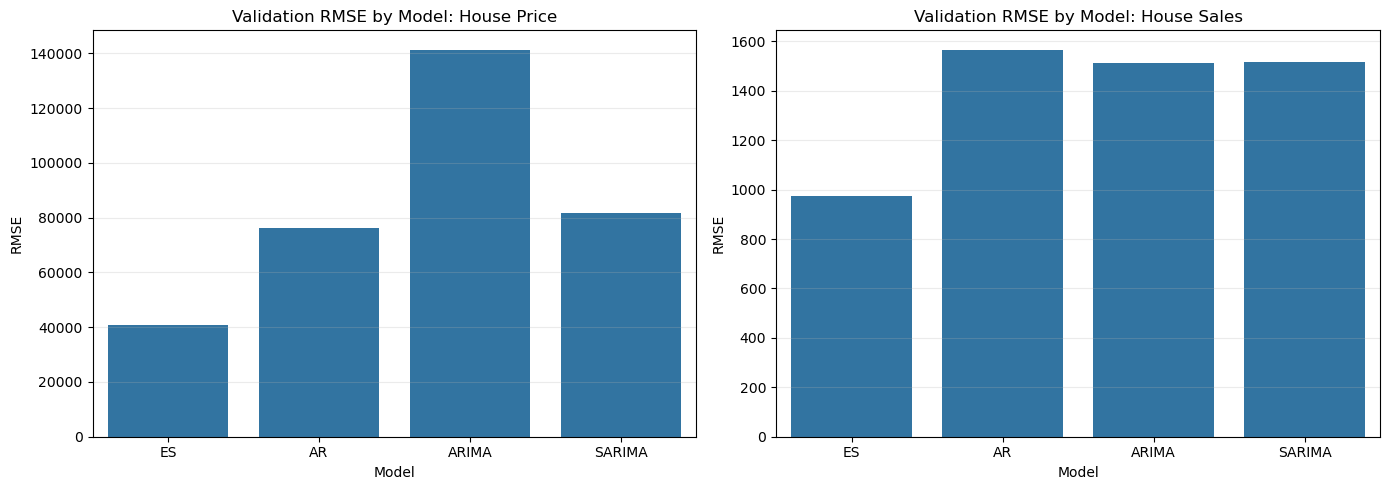

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="white")

targets = ["House_Price", "House_Sales"]
titles = ["Validation RMSE by Model: House Price", "Validation RMSE by Model: House Sales"]

for ax, target, title in zip(axes, targets, titles):
    plot_data = Forecast_model_comparison[
        Forecast_model_comparison["Target"] == target
    ]

    sns.barplot(
        data=plot_data,
        x="Model",
        y="RMSE",
        ax=ax
    )

    ax.set_facecolor("white")
    ax.set_title(title)
    ax.set_xlabel("Model")
    ax.set_ylabel("RMSE")
    ax.grid(True, axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## Final SARIMA forecast on the test set

The final model uses `Final_train_data = Train_clean + Validate`. Forecast length is always `len(Test)`, and there is no hardcoded index.

In [13]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

Final_train_data = pd.concat(
    [Train_clean, Validate],
    ignore_index=True
).copy()

Test = Test.copy()

final_models = {}
final_forecasts = {}

for target in TARGET_COLUMNS:
    y_final_train = Final_train_data[target].reset_index(drop=True)

    model = SARIMAX(
        y_final_train,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, SEASONAL_PERIODS),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fit = model.fit(disp=False)

    forecast = pd.Series(
        fit.forecast(steps=len(Test)),
        index=Test.index,
        name=f"Forecast_{target}"
    )

    final_models[target] = fit
    final_forecasts[target] = forecast

    Test.loc[:, f"Forecast_{target}"] = forecast

display(
    Test[
        [
            "Date",
            "House_Price",
            "Forecast_House_Price",
            "House_Sales",
            "Forecast_House_Sales"
        ]
    ].head()
)

,Date,House_Price,Forecast_House_Price,House_Sales,Forecast_House_Sales
130,2020-01-01,884385.00,897181.76,1603.00,1510.83
131,2020-02-01,989218.00,952191.85,2477.00,2244.13
132,2020-03-01,987787.00,991119.37,2771.00,3124.09
133,2020-04-01,881424.00,1006220.62,1036.00,3551.91
134,2020-05-01,955273.00,1018427.97,1491.00,3815.82


## Final test metrics

MAPE is multiplied by 100 and shown as a percentage.

In [14]:
test_metrics = pd.concat([
    regression_metrics(Test["House_Price"], Test["Forecast_House_Price"], "Final SARIMA", "House_Price"),
    regression_metrics(Test["House_Sales"], Test["Forecast_House_Sales"], "Final SARIMA", "House_Sales")
], ignore_index=True)

test_metrics

,Model,Target,MAE,RMSE,MAPE (%)
0,Final SARIMA,House_Price,74553.21,90245.98,7.00
1,Final SARIMA,House_Sales,839.02,957.54,39.20


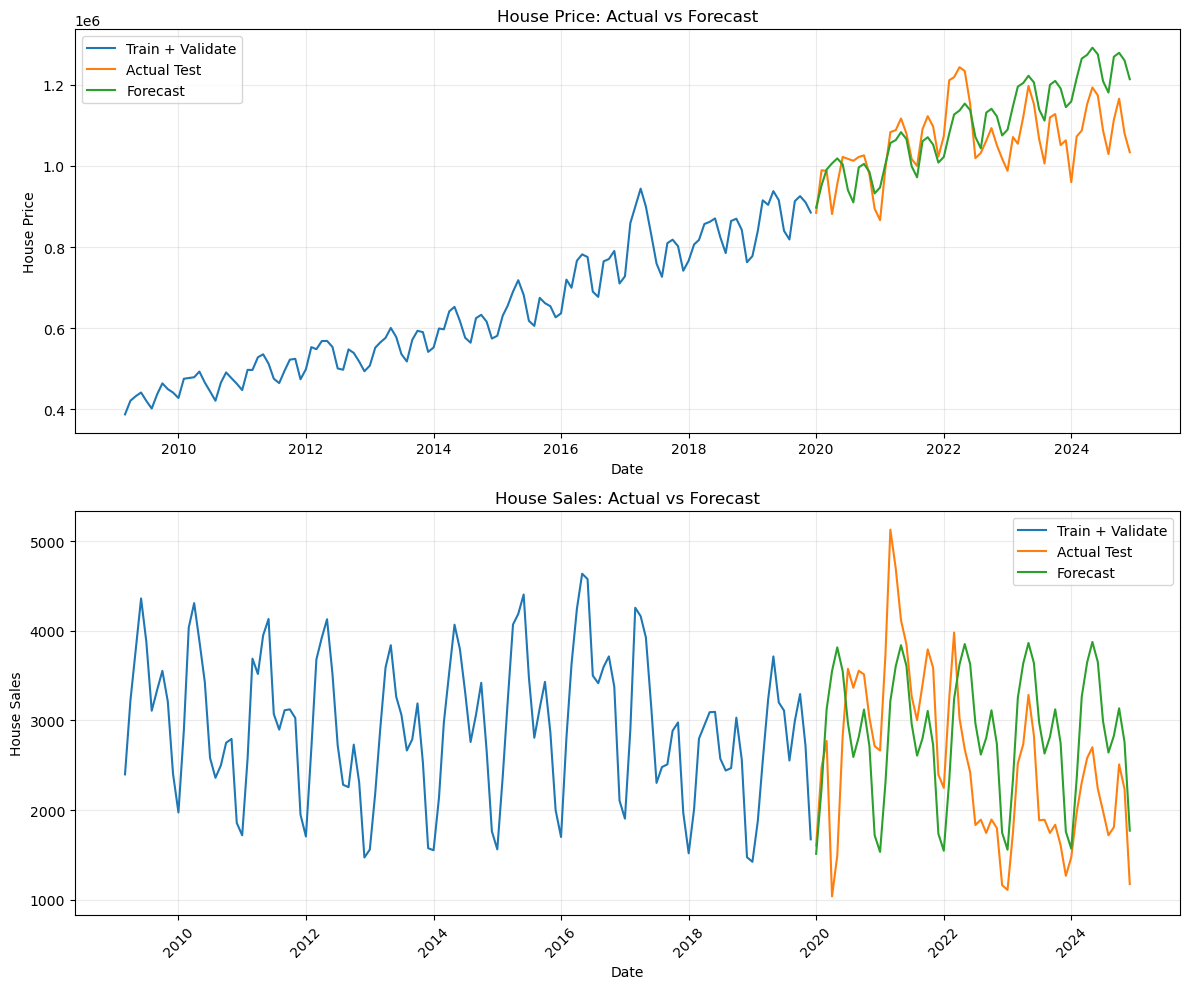

In [15]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), facecolor="white")

for ax in (ax1, ax2):
    ax.set_facecolor("white")
    ax.grid(True, alpha=0.25)

ax1.plot(Final_train_data["Date"], Final_train_data["House_Price"], label="Train + Validate")
ax1.plot(Test["Date"], Test["House_Price"], label="Actual Test")
ax1.plot(Test["Date"], Test["Forecast_House_Price"], label="Forecast")
ax1.set_title("House Price: Actual vs Forecast")
ax1.set_xlabel("Date")
ax1.set_ylabel("House Price")
ax1.legend()

ax2.plot(Final_train_data["Date"], Final_train_data["House_Sales"], label="Train + Validate")
ax2.plot(Test["Date"], Test["House_Sales"], label="Actual Test")
ax2.plot(Test["Date"], Test["Forecast_House_Sales"], label="Forecast")
ax2.set_title("House Sales: Actual vs Forecast")
ax2.set_xlabel("Date")
ax2.set_ylabel("House Sales")
ax2.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()